# Классификация ботов по потоку событий

**Итоговый ноутбук для проверки:** [solution.ipynb](solution.ipynb). Он содержит описание подхода, весь код финальной модели и создает воспроизводимый `submission.csv`.

Ноутбук содержит исследование данных, сравнение базовых моделей, отбор
поведенческих признаков и эксперимент с совместными координатами X/Y.
Последний раздел создает `submissions/catboost_behavior_xy.csv`;
вариант без координат сохранен в `submissions/catboost_behavior_selected.csv`.

Условие и описание метрики — в [TASK.md](../TASK.md).
Отбор 30 признаков — [BEHAVIOR_REPORT.md](BEHAVIOR_REPORT.md).
XY-эксперимент — [POINTER_REPORT.md](POINTER_REPORT.md).


In [1]:
import numpy as np
import pandas as pd

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv',
                   parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [2]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [3]:
# Дубликаты

for name, df in [('train', train), ('test', test), ('events', events)]:
    duplicates = df.duplicated()
    duplicate_group = df.duplicated(keep=False)

    print(f'{name}: полных повторов сверх первой строки — {duplicates.sum()}')
    print(f'Строк в группах дубликатов, включая первые: {duplicate_group.sum()}')

    if duplicate_group.any():
        display(
            df.loc[duplicate_group]
            .sort_values(list(df.columns))
            .head(10)
        )

# В train/test ожидаем одну строку на cookie_id.
# В events одна cookie может иметь много разных событий — это нормально.
for name, df in [('train', train), ('test', test)]:
    repeated_cookies = df.duplicated(subset=['cookie_id'], keep=False)
    n_cookies = df.loc[repeated_cookies, 'cookie_id'].nunique()

    print(f'{name}: cookie_id с несколькими строками — {n_cookies}')
    if repeated_cookies.any():
        display(df.loc[repeated_cookies].sort_values('cookie_id').head(10))


train: полных повторов сверх первой строки — 0
Строк в группах дубликатов, включая первые: 0
test: полных повторов сверх первой строки — 0
Строк в группах дубликатов, включая первые: 0
events: полных повторов сверх первой строки — 4863
Строк в группах дубликатов, включая первые: 9726


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
210391,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
24981,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
102678,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
80882,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244462,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


train: cookie_id с несколькими строками — 0
test: cookie_id с несколькими строками — 0


In [4]:
# Удаляем полные дубликаты, оставляя первый экземпляр каждого события.
n_events_before = len(events)
events = events.drop_duplicates(keep='first').reset_index(drop=True)

print(f'Удалено дубликатов: {n_events_before - len(events)}')
print(f'Осталось событий: {len(events)}')

Удалено дубликатов: 4863
Осталось событий: 324042


## Осмотреться

Прежде чем считать агрегаты, стоит посмотреть на данные: какие типы событий бывают, что
лежит в `platform` и `user_agent`, где пропуски, все ли уникально.

In [5]:
print(events.event_name.value_counts(), '\n')
print(events.platform.value_counts(), '\n')
print('пропуски по колонкам:')
print(events.isna().mean().round(3))

event_name
item_view               118990
search_results_view      98929
photo_swipe              35962
favorite_add             18739
seller_page_view         17180
contact_phone_show       11154
captcha_shown             7831
login                     6178
contact_chat_open         6047
contact_message_sent      3032
Name: count, dtype: int64 

platform
desktop    46157
WEB        45799
Web        45703
web        45284
ANDROID    41809
Android    41637
android    41542
iOS         4035
iphone      4035
IOS         4028
ios         4013
Name: count, dtype: int64 

пропуски по колонкам:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.349
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64


In [6]:
# Типы событий и их количество
(
    events.groupby(['eid', 'event_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

,eid,event_name,count
1,200,item_view,118990
0,100,search_results_view,98929
2,210,photo_swipe,35962
7,400,favorite_add,18739
3,220,seller_page_view,17180
4,300,contact_phone_show,11154
9,900,captcha_shown,7831
8,500,login,6178
5,301,contact_chat_open,6047
6,303,contact_message_sent,3032


In [7]:
# Тип данных каждого поля в events
def readable_dtype(dtype):
    if pd.api.types.is_datetime64_any_dtype(dtype):
        return 'Дата и время'
    if pd.api.types.is_bool_dtype(dtype):
        return 'Логический (True / False)'
    if pd.api.types.is_integer_dtype(dtype):
        return 'Целое число'
    if pd.api.types.is_float_dtype(dtype):
        return 'Число с плавающей точкой'
    if isinstance(dtype, pd.CategoricalDtype):
        return 'Категория'
    if pd.api.types.is_string_dtype(dtype):
        return 'Текст'
    return str(dtype)

column_types = pd.DataFrame({
    'dtype': events.dtypes.astype(str),
    'Тип данных': events.dtypes.map(readable_dtype),
}).rename_axis('Поле')

column_types


,dtype,Тип данных
Поле,,
cookie_id,object,Текст
event_ts,datetime64[ns],Дата и время
eid,int64,Целое число
event_name,object,Текст
platform,object,Текст
user_agent,object,Текст
item_id,float64,Число с плавающей точкой
item_category,object,Текст
item_location,object,Текст


***platform***

In [8]:
# Уникальные значения поля "platform"
print(events['platform'].unique())

['desktop' 'web' 'WEB' 'Web' 'Android' 'IOS' 'ANDROID' 'android' 'ios'
 'iOS' 'iphone']


In [9]:
#Можем объединить 'web' с 'desktop', так как desktop и web имеют одинаковые user_agent
p = events['platform'].str.strip().str.lower()

desktop_ua = set(events.loc[p == 'desktop', 'user_agent'])
web_ua = set(events.loc[p == 'web', 'user_agent'])

print(desktop_ua == web_ua)  # True


True


In [10]:
#значение 'web' включается в себя: 'desktop' 'web' 'WEB' 'Web'. можем объединить 'web' с 'desktop', так как desktop и web имеют одинаковые user_agent
#значение 'android' включается в себя: 'Android', 'ANDROID' 'android'
#значение 'ios' включается в себя: 'IOS', 'ios', 'iOS'

events['platform'] = (
    events['platform']
    .str.strip()
    .str.lower()
    .replace({'iphone': 'ios', 'desktop': 'web'})
  )

print(events['platform'].unique())


['web' 'android' 'ios']


***user_agent***

In [11]:
#Уникальные значения поля "user_agent"
print(events['user_agent'].unique())


['Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:113.0) Gecko/20100101 Firefox/113.0'
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/113.0.0.0 YaBrowser/23.5.0.0 Safari/537.36'
 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36'
 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
 'Avito/122.0 (Android 11; M2101K6G) okhttp/4.11.0'
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 YaBrowser/23.3.0.0 Safari/537.36'
 'Mozilla/5.0 (iPhone; CPU iPhone OS 15_2 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/15.0 M

In [12]:
print(events['user_agent'].nunique())

148


In [13]:
# создадим новые столбцы на основе данных из "user_agent"
ua = events['user_agent'].fillna('').str.lower()

events['ua_os'] = np.select(
    [
        ua.str.contains('android'),
        ua.str.contains(r'iphone|ipad|\bios\b'),
        ua.str.contains('windows'),
        ua.str.contains(r'macintosh|mac os x'),
        ua.str.contains('linux'),
    ],
    ['android', 'ios', 'windows', 'macos', 'linux'],
    default='unknown',
)

http_client = ua.str.match(
    r'^(?:python-requests|python-urllib3|curl|scrapy|go-http-client|node-fetch)/'
)

events['ua_client'] = np.select(
    [
        ua.str.startswith('avito/'),
        http_client,
        ua.str.contains('yabrowser/'),
        ua.str.contains('headlesschrome/'),
        ua.str.contains('chrome/'),
        ua.str.contains('firefox/'),
        ua.str.contains('safari/'),
    ],
    [
        'avito_app', 'http_client', 'yandex', 'headless_chrome',
        'chrome', 'firefox', 'safari',
    ],
    default='other',
)

events['ua_is_headless'] = events['ua_client'].eq('headless_chrome')
events['ua_is_http_client'] = http_client

In [14]:
events.head(5)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,ua_os,ua_client,ua_is_headless,ua_is_http_client
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN,macos,chrome,False,False
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN,windows,firefox,False,False
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0,windows,yandex,False,False
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN,macos,chrome,False,False
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN,macos,chrome,False,False


In [15]:
# Все события cookie, помеченных в train как боты (target == 1).
bot_events = (
    train.loc[train['target'].eq(1)]
    .merge(events, on='cookie_id', how='inner', validate='one_to_many')
    .sort_values(['cookie_id', 'event_ts'])
    .reset_index(drop=True)
)

# Для расчета признаков подходят события с in_window == True.
bot_events['in_window'] = (
    bot_events['event_ts'].ge(bot_events['window_start_ts'])
    & bot_events['event_ts'].lt(bot_events['window_end_ts'])
)

print(f'Уникальных cookie_id ботов: {bot_events["cookie_id"].nunique()}')
print(f'Строк событий после объединения: {len(bot_events)}')
print(f'Событий внутри окна наблюдения: {bot_events["in_window"].sum()}')

# Все уникальные непустые значения сохраняем по названиям столбцов.
bot_unique_values = {
    column: bot_events[column].dropna().unique().tolist()
    for column in bot_events.columns
}

# Ограничиваем только вывод длинных списков, например дат и ID.
max_unique_to_show = 200

for column, values in bot_unique_values.items():
    n_missing = bot_events[column].isna().sum()
    print(f'\n{column}: уникальных значений — {len(values)}, пропусков — {n_missing}')

    if len(values) > max_unique_to_show:
        print(f'Показаны первые {max_unique_to_show}; полный список: bot_unique_values[{column!r}]')

    print(values[:max_unique_to_show])


Уникальных cookie_id ботов: 899
Строк событий после объединения: 45424
Событий внутри окна наблюдения: 26105

cookie_id: уникальных значений — 899, пропусков — 0
Показаны первые 200; полный список: bot_unique_values['cookie_id']
['ck_00389b209b37394b', 'ck_00708a91ae901fee', 'ck_0079bcdec7174306', 'ck_010e6322abe5cfdf', 'ck_012587ae7bc0bffe', 'ck_01278cd93f50ba5f', 'ck_014db4f6010cac2b', 'ck_01e05b9020e4d93b', 'ck_02054bf840f7a2e5', 'ck_02198cac9e1cc48a', 'ck_0252050372ee3ce9', 'ck_03650807581d2799', 'ck_038d5fe2e8a1681e', 'ck_0392839444805ff9', 'ck_03ce65cbb2ccbc78', 'ck_03dcbc92e033355a', 'ck_044ff2bfd09d3371', 'ck_047e452414925eaf', 'ck_04ef765947ef16ed', 'ck_0557c7c63d91597e', 'ck_062d715feadd3e09', 'ck_067e661e6216bdc0', 'ck_068c949054861217', 'ck_06e8c1ad135c4cc4', 'ck_078002b4b4948138', 'ck_079f4ad65c13e2be', 'ck_07d1e516945d42cc', 'ck_07d2d1686812e0a5', 'ck_07ddf044e280435d', 'ck_07e48ae012535cd8', 'ck_07f55d0151f8ab94', 'ck_07f65a99b0377def', 'ck_083951c0c3a5ef58', 'ck_086b592

In [16]:
# Уникальные eid людей по всей истории, как в выборке bot_events выше.
human_cookie_ids = train.loc[train['target'].eq(0), 'cookie_id']
human_eid = events.loc[events['cookie_id'].isin(human_cookie_ids), 'eid']
print(f'eid у людей: уникальных значений — {human_eid.nunique()}, пропусков — {human_eid.isna().sum()}')
print(sorted(human_eid.dropna().unique().tolist()))


eid у людей: уникальных значений — 10, пропусков — 0
[100, 200, 210, 220, 300, 301, 303, 400, 500, 900]


## Окно наблюдения

Признаки считаем только по событиям внутри окна: `window_start_ts <= event_ts < window_end_ts`.
Это требование из условия, а не рекомендация.

In [17]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

195484 88349


## Признаки по cookie_id

Одна строка — одна cookie. Считаем общее количество событий, количество действий каждого
типа и число уникальных объявлений, категорий, локаций и поисковых запросов.
Используем только события внутри окна наблюдения. Пропуски не считаются отдельными
объявлениями или запросами; если событий нет, все счетчики равны нулю.

`Xtr` и `Xte` содержат признаки без целевой метки. В `train_features` добавлена метка
`target` для сравнения групп, а `bot_features` содержит только ботов.


In [18]:
EVENT_TYPES = [
    'search_results_view', 'item_view', 'photo_swipe', 'seller_page_view',
    'contact_phone_show', 'contact_chat_open', 'contact_message_sent',
    'favorite_add', 'login', 'captcha_shown',
]


def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = g.agg(
        n_events=('event_ts', 'size'),
        event_type_nunique=('event_name', 'nunique'),
        item_nunique=('item_id', 'nunique'),
        item_category_nunique=('item_category', 'nunique'),
        item_location_nunique=('item_location', 'nunique'),
        search_query_nunique=('search_query', 'nunique'),
    )

    # Одинаковые столбцы в train и test, даже если какой-то тип событий отсутствует.
    event_counts = (
        pd.crosstab(ev['cookie_id'], ev['event_name'])
        .reindex(columns=EVENT_TYPES, fill_value=0)
        .add_prefix('n_')
    )
    f = f.join(event_counts)
    f = meta[['cookie_id']].merge(
        f, on='cookie_id', how='left', validate='one_to_one',
    )
    count_columns = f.columns.drop('cookie_id')
    f[count_columns] = f[count_columns].fillna(0).astype('int64')
    return f


Xtr = basic_features(ev_tr, train)
Xte = basic_features(ev_te, test)
ytr = train['target'].to_numpy()

train_features = train[['cookie_id', 'target']].merge(
    Xtr, on='cookie_id', how='left', validate='one_to_one',
)
bot_features = train_features.loc[train_features['target'].eq(1)].reset_index(drop=True)
human_features = train_features.loc[train_features['target'].eq(0)].reset_index(drop=True)

print(f'Train: {len(train_features)} строк; test: {len(Xte)} строк')
print(f'Людей: {len(human_features)}; ботов: {len(bot_features)}')
print(f'Числовых признаков: {Xtr.shape[1] - 1}')
display(train_features.head(10))


Train: 11091 строк; test: 4909 строк
Людей: 10192; ботов: 899
Числовых признаков: 16


,cookie_id,target,n_events,event_type_nunique,item_nunique,item_category_nunique,item_location_nunique,search_query_nunique,n_search_results_view,n_item_view,n_photo_swipe,n_seller_page_view,n_contact_phone_show,n_contact_chat_open,n_contact_message_sent,n_favorite_add,n_login,n_captcha_shown
0,ck_54a059eb7d3ea68b,0,7,3,4,3,5,3,3,3,1,0,0,0,0,0,0,0
1,ck_7e4de46eeab82974,0,41,7,19,1,12,5,8,22,4,4,1,0,0,1,1,0
2,ck_9320229ef6304522,0,36,9,19,7,9,10,13,7,3,3,2,1,1,3,3,0
3,ck_30ccd25bc1714ed9,0,21,5,10,1,4,3,3,14,0,2,1,1,0,0,0,0
4,ck_a77c5f05948cdeef,0,28,6,16,4,6,6,6,12,4,3,1,0,0,2,0,0
5,ck_ea6f843af2292fec,0,18,6,10,5,5,6,7,4,2,0,1,0,1,3,0,0
6,ck_e38634dc2f188574,0,10,6,6,3,5,1,1,3,3,1,1,1,0,0,0,0
7,ck_ad7f01440bb250d1,0,23,7,7,1,8,3,6,9,1,1,0,1,2,3,0,0
8,ck_a7a58d28a4482bdc,0,4,3,2,2,3,2,2,1,0,0,0,0,0,1,0,0
9,ck_e00e1e6c2a2ab4ac,1,20,6,9,6,4,9,11,5,1,0,1,1,0,1,0,0


## Распределения признаков: люди и боты

На каждом графике сравниваем один признак для двух групп. По оси Y — доля cookie
внутри своей группы, а не абсолютное число: людей в train значительно больше, чем ботов.
Интервалы гистограмм одинаковы для обеих групп; показан полный диапазон значений.

Графики сохраняются в `artifacts/bot_human_distributions.png`.


n_events        n_item_view        item_nunique         \
          median   mean      median   mean       median   mean   
group                                                            
Бот         20.0  29.04         8.0  12.68         10.0  13.78   
Человек     12.0  16.62         4.0   6.06          6.0   8.92   

        n_search_results_view         
                       median   mean  
group                                 
Бот                       7.0  10.21  
Человек                   4.0   5.07

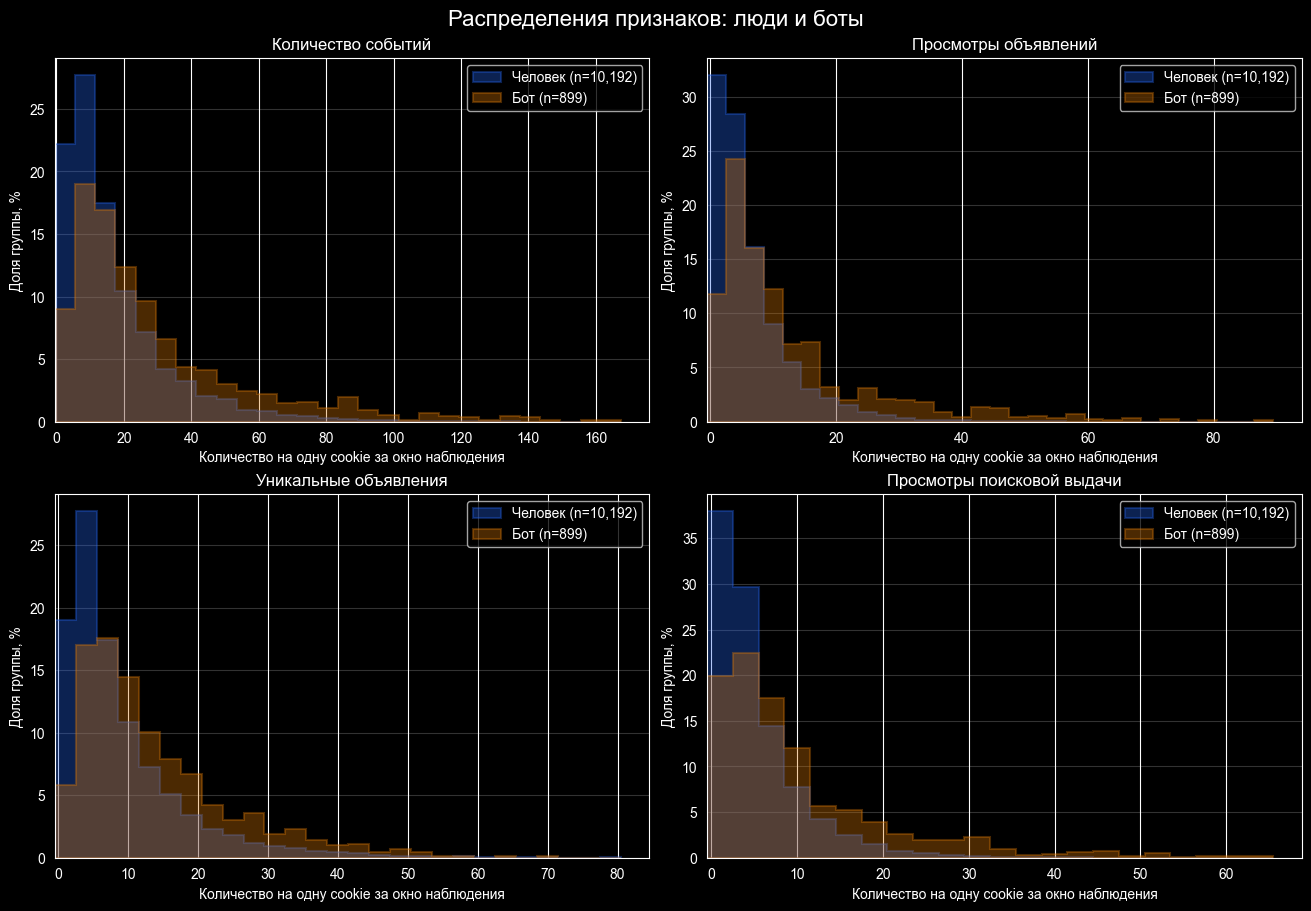

In [19]:
from pathlib import Path
import matplotlib.pyplot as plt

features_to_plot = {
    'n_events': 'Количество событий',
    'n_item_view': 'Просмотры объявлений',
    'item_nunique': 'Уникальные объявления',
    'n_search_results_view': 'Просмотры поисковой выдачи',
}

distribution_summary = (
    train_features.assign(group=train_features['target'].map({0: 'Человек', 1: 'Бот'}))
    .groupby('group')[list(features_to_plot)]
    .agg(['median', 'mean'])
    .round(2)
)
display(distribution_summary)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout='constrained')
for ax, (feature, title) in zip(axes.flat, features_to_plot.items()):
    max_value = int(train_features[feature].max())
    bin_width = max(1, int(np.ceil((max_value + 1) / 30)))
    bins = np.arange(-0.5, max_value + bin_width + 0.5, bin_width)

    for target, label, color in [(0, 'Человек', '#2563eb'), (1, 'Бот', '#d97706')]:
        values = train_features.loc[train_features['target'].eq(target), feature]
        if values.empty:
            continue
        ax.hist(
            values, bins=bins,
            weights=np.full(len(values), 100.0 / len(values)),
            histtype='stepfilled', alpha=0.35, linewidth=1.5,
            color=color, edgecolor=color, label=f'{label} (n={len(values):,})',
        )

    ax.set_title(title)
    ax.set_xlabel('Количество на одну cookie за окно наблюдения')
    ax.set_ylabel('Доля группы, %')
    ax.set_xlim(left=-0.5)
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend()

fig.suptitle('Распределения признаков: люди и боты', fontsize=16)
plot_dir = Path('artifacts')
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / 'bot_human_distributions.png', dpi=160, bbox_inches='tight')
plt.show()


## Время событий: люди и боты

Здесь одно наблюдение — событие внутри окна train. Сравниваем `event_ts` по датам
и по часам суток. По оси Y — доля событий внутри своей группы; число событий
каждой группы указано в легенде. Часы берем из `event_ts` без изменения часового пояса.

Графики сохраняются в `artifacts/bot_human_event_times.png`.


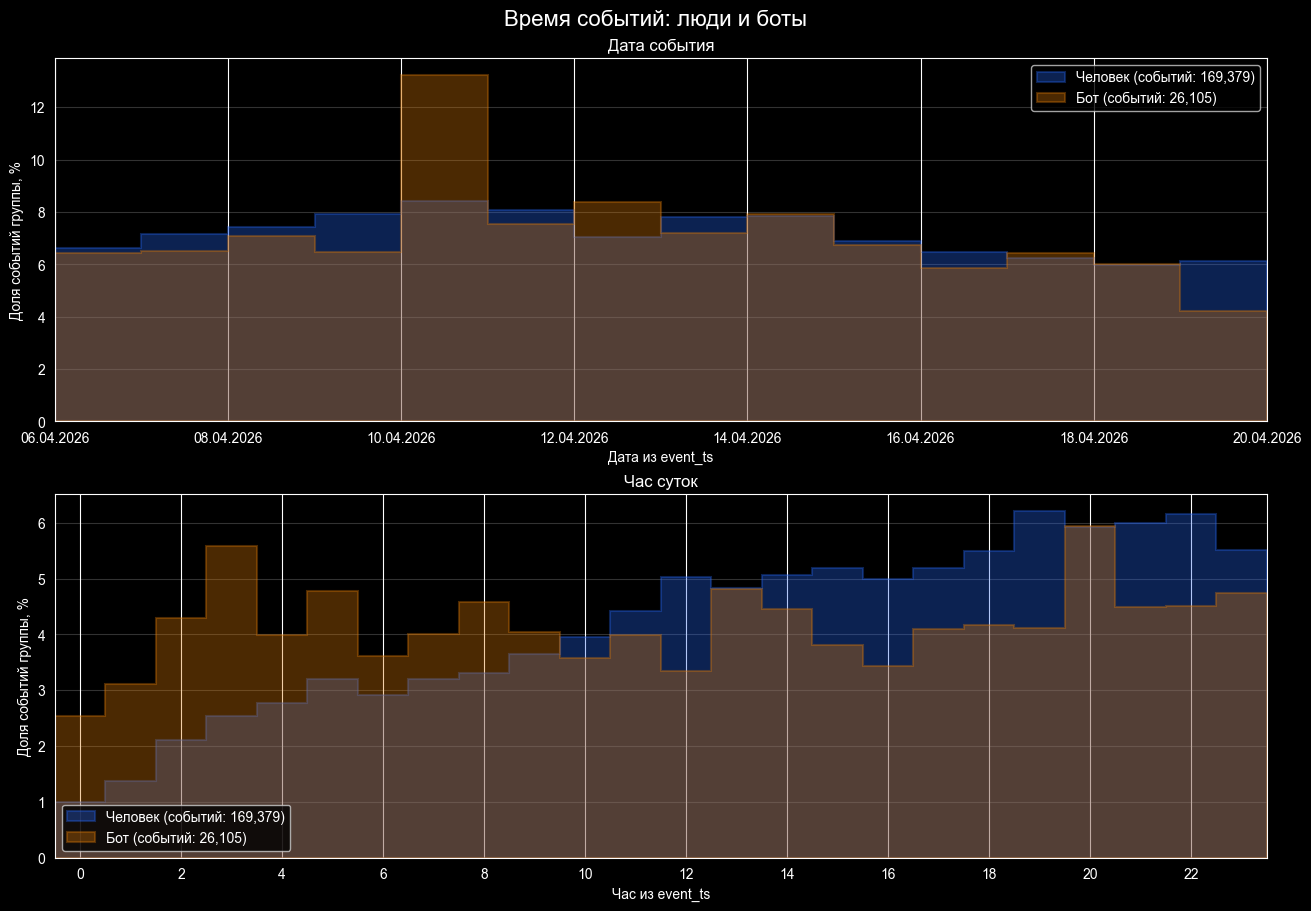

In [20]:
import matplotlib.dates as mdates

time_events = ev_tr[['cookie_id', 'event_ts']].merge(
    train[['cookie_id', 'target']], on='cookie_id', how='left', validate='many_to_one',
)
date_edges = pd.date_range(
    train['window_start_ts'].min().normalize(),
    train['window_end_ts'].max().ceil('D'),
    freq='D',
)
date_bins = mdates.date2num(date_edges.to_numpy())
hour_bins = np.arange(-0.5, 24.5, 1)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), layout='constrained')
for target, label, color in [(0, 'Человек', '#2563eb'), (1, 'Бот', '#d97706')]:
    timestamps = time_events.loc[time_events['target'].eq(target), 'event_ts']
    if timestamps.empty:
        continue
    weights = np.full(len(timestamps), 100.0 / len(timestamps))
    histogram_options = dict(
        weights=weights, histtype='stepfilled', alpha=0.35,
        linewidth=1.5, color=color, edgecolor=color,
        label=f'{label} (событий: {len(timestamps):,})',
    )
    axes[0].hist(mdates.date2num(timestamps.to_numpy()), bins=date_bins, **histogram_options)
    axes[1].hist(timestamps.dt.hour, bins=hour_bins, **histogram_options)

axes[0].set_title('Дата события')
axes[0].set_xlabel('Дата из event_ts')
axes[0].xaxis_date()
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
axes[0].set_xlim(date_bins[0], date_bins[-1])
axes[1].set_title('Час суток')
axes[1].set_xlabel('Час из event_ts')
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlim(-0.5, 23.5)

for ax in axes:
    ax.set_ylabel('Доля событий группы, %')
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend()

fig.suptitle('Время событий: люди и боты', fontsize=16)
fig.savefig(plot_dir / 'bot_human_event_times.png', dpi=160, bbox_inches='tight')
plt.show()


## Категории, города и типы продавцов

Сравниваем уникальные cookie по событиям внутри окна train. На графиках категорий
и типов продавцов показана доля cookie своей группы, у которых встретилось значение.
Одна cookie может встречаться в нескольких категориях или городах, поэтому доли
не обязаны суммироваться до 100%. Пропуски не подменяем отдельной категорией.

Для городов считаем долю ботов среди всех cookie, у которых были события
с данным `item_location`. Это город объявления, а не установленное местоположение
пользователя. Рядом с каждой долей указаны число ботов и общее число cookie.


Доля пропусков среди событий внутри окна, %:


,item_category,item_location,seller_type,pointer_x,pointer_y
target,,,,,
Человек,8.03,5.13,38.76,65.25,65.25
Бот,6.92,3.83,41.60,75.42,75.42


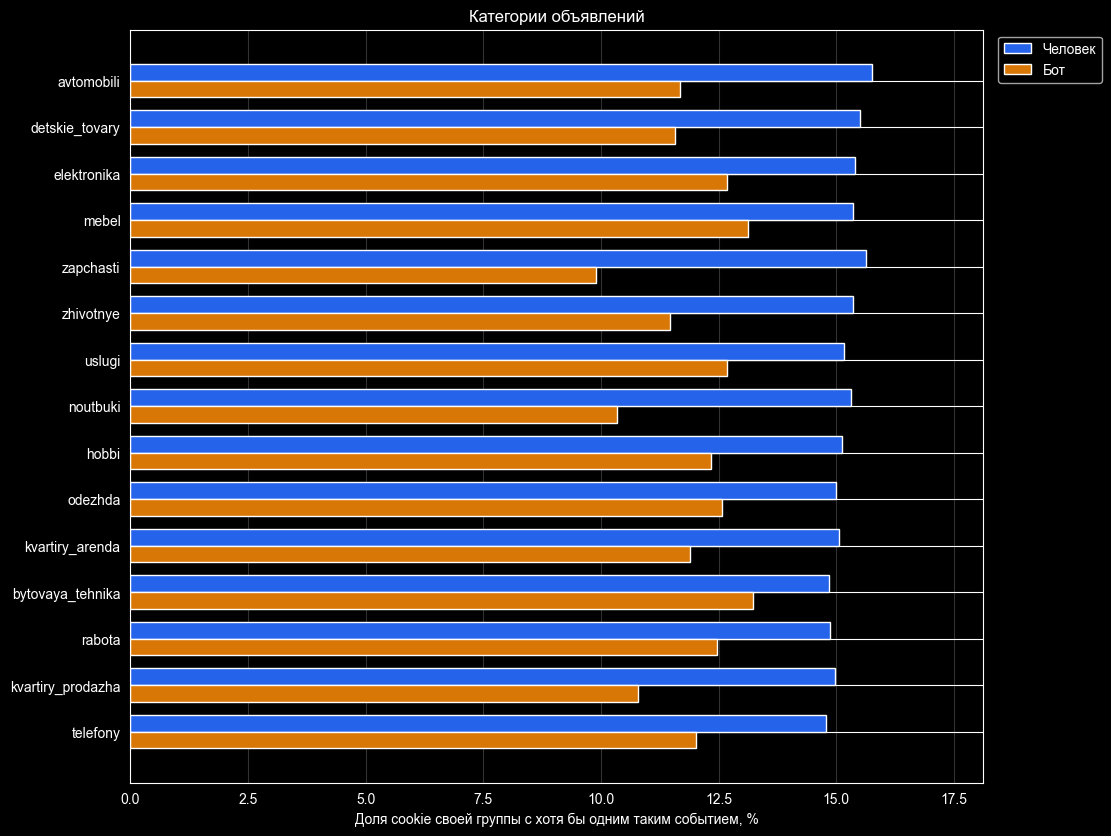

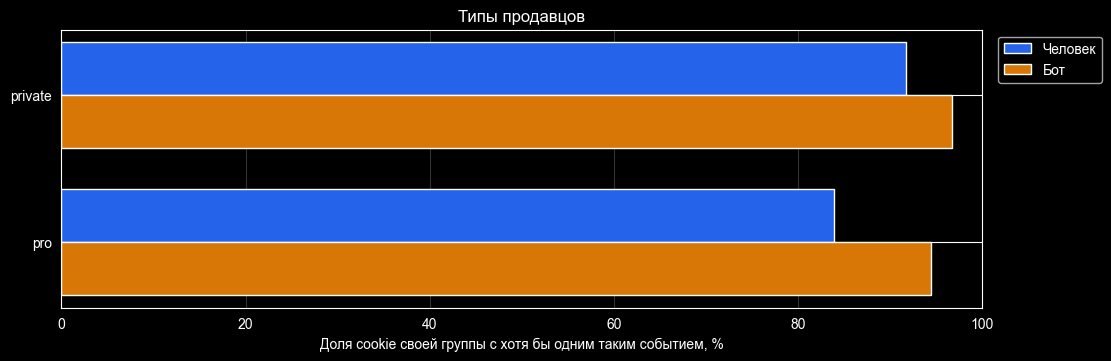

Города: доля ботов среди уникальных cookie с событиями в городе:


,human_cookies,bot_cookies,human_pct,bot_pct,total_cookies,bot_share_pct
item_location,,,,,,
orenburg,1063,200,10.43,22.25,1263,15.84
ufa,1128,207,11.07,23.03,1335,15.51
ulyanovsk,1129,205,11.08,22.80,1334,15.37
barnaul,1187,213,11.65,23.69,1400,15.21
voronezh,1111,197,10.90,21.91,1308,15.06
nizhniy_novgorod,1094,193,10.73,21.47,1287,15.00
ryazan,1174,200,11.52,22.25,1374,14.56
samara,1102,185,10.81,20.58,1287,14.37
kemerovo,1110,186,10.89,20.69,1296,14.35


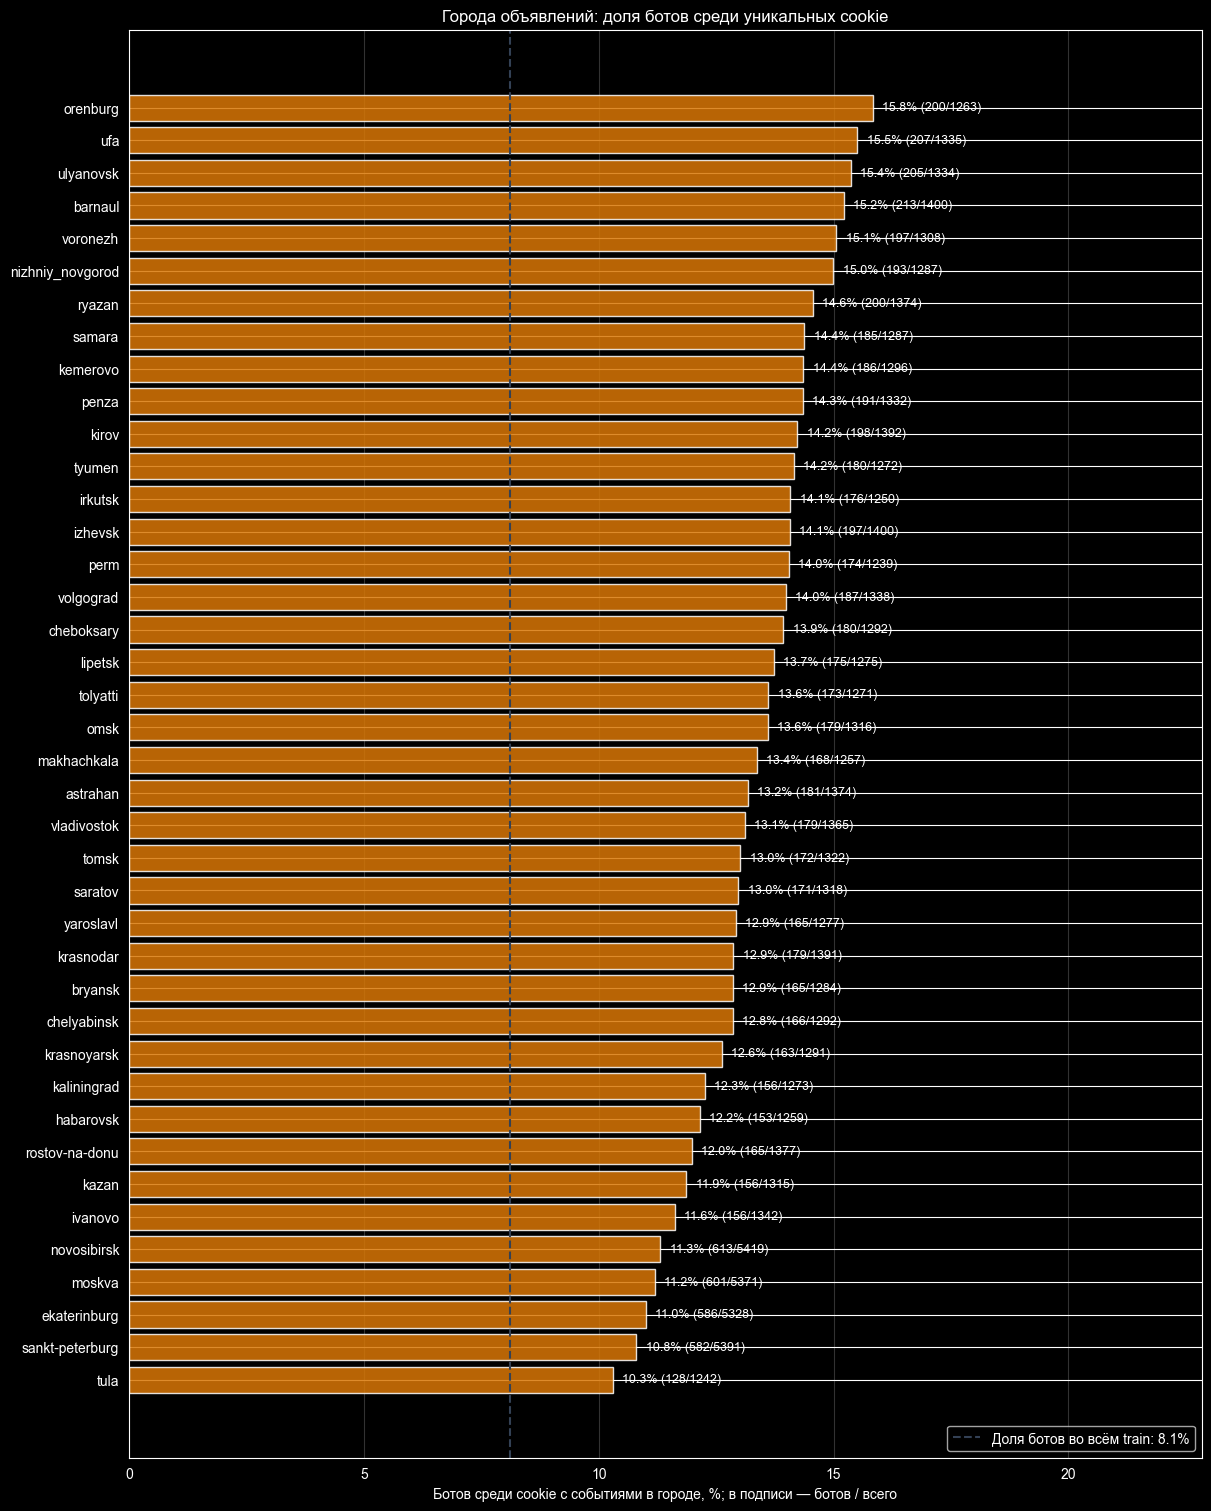

In [21]:
train_events_labeled = ev_tr.merge(
    train[['cookie_id', 'target']], on='cookie_id', how='left', validate='many_to_one',
)
class_sizes = train.groupby('target')['cookie_id'].nunique()


def compare_cookie_values(column):
    # Каждая cookie учитывается один раз для каждого известного значения поля.
    observed = (
        train_events_labeled.dropna(subset=[column])
        .drop_duplicates(['cookie_id', column])
    )
    table = (
        observed.groupby([column, 'target']).size().unstack(fill_value=0)
        .reindex(columns=[0, 1], fill_value=0)
        .rename(columns={0: 'human_cookies', 1: 'bot_cookies'})
    )
    table.columns.name = None
    table['human_pct'] = 100 * table['human_cookies'] / class_sizes.loc[0]
    table['bot_pct'] = 100 * table['bot_cookies'] / class_sizes.loc[1]
    table['total_cookies'] = table['human_cookies'] + table['bot_cookies']
    table['bot_share_pct'] = 100 * table['bot_cookies'] / table['total_cookies']
    return table


category_comparison = compare_cookie_values('item_category')
location_comparison = compare_cookie_values('item_location')
seller_comparison = compare_cookie_values('seller_type')

missing_pct_by_class = (
    train_events_labeled.groupby('target')[
        ['item_category', 'item_location', 'seller_type', 'pointer_x', 'pointer_y']
    ]
    .agg(lambda values: values.isna().mean() * 100)
    .rename(index={0: 'Человек', 1: 'Бот'})
    .round(2)
)
print('Доля пропусков среди событий внутри окна, %:')
display(missing_pct_by_class)

for table, title, filename in [
    (category_comparison, 'Категории объявлений', 'bot_human_item_categories.png'),
    (seller_comparison, 'Типы продавцов', 'bot_human_seller_types.png'),
]:
    ordered = table.sort_values('total_cookies', ascending=False)
    y = np.arange(len(ordered))
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * len(ordered) + 1.5)), layout='constrained')
    ax.barh(y - 0.18, ordered['human_pct'], height=0.36, color='#2563eb', label='Человек')
    ax.barh(y + 0.18, ordered['bot_pct'], height=0.36, color='#d97706', label='Бот')
    ax.set_yticks(y, ordered.index.astype(str))
    ax.invert_yaxis()
    max_pct = ordered[['human_pct', 'bot_pct']].to_numpy().max()
    ax.set_xlim(0, min(100, max_pct * 1.15))
    ax.set_xlabel('Доля cookie своей группы с хотя бы одним таким событием, %')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    fig.savefig(plot_dir / filename, dpi=160, bbox_inches='tight')
    plt.show()

location_comparison = location_comparison.sort_values('bot_share_pct', ascending=False)
print('Города: доля ботов среди уникальных cookie с событиями в городе:')
display(location_comparison.round(2))

fig, ax = plt.subplots(figsize=(12, 15), layout='constrained')
y = np.arange(len(location_comparison))
ax.barh(y, location_comparison['bot_share_pct'], color='#d97706', alpha=0.85)
ax.set_yticks(y, location_comparison.index.astype(str))
ax.invert_yaxis()
for position, row in enumerate(location_comparison.itertuples()):
    ax.text(
        row.bot_share_pct + 0.2, position,
        f'{row.bot_share_pct:.1f}% ({row.bot_cookies}/{row.total_cookies})',
        va='center', fontsize=9,
    )
baseline_bot_share = 100 * train['target'].mean()
ax.axvline(baseline_bot_share, color='#334155', linestyle='--',
           label=f'Доля ботов во всем train: {baseline_bot_share:.1f}%')
ax.set_xlim(0, location_comparison['bot_share_pct'].max() + 7)
ax.set_xlabel('Ботов среди cookie с событиями в городе, %; в подписи — ботов / всего')
ax.set_title('Города объявлений: доля ботов среди уникальных cookie')
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)
ax.legend(loc='lower right')
fig.savefig(plot_dir / 'bot_share_by_item_location.png', dpi=160, bbox_inches='tight')
plt.show()


## Координаты курсора: люди и боты

Берем события `web` с обеими координатами. Для каждой cookie считаем медиану X и Y:
так каждая cookie дает одно наблюдение независимо от числа ее событий.
На диаграммах показаны медианы, межквартильные интервалы, усы до 1.5 IQR
и отдельные точки за усами. Cookie без координат в диаграммы не входят.


,web_cookies,cookies_with_coordinates,with_coordinates_pct
target,,,
Человек,5329,3795,71.21
Бот,588,251,42.69


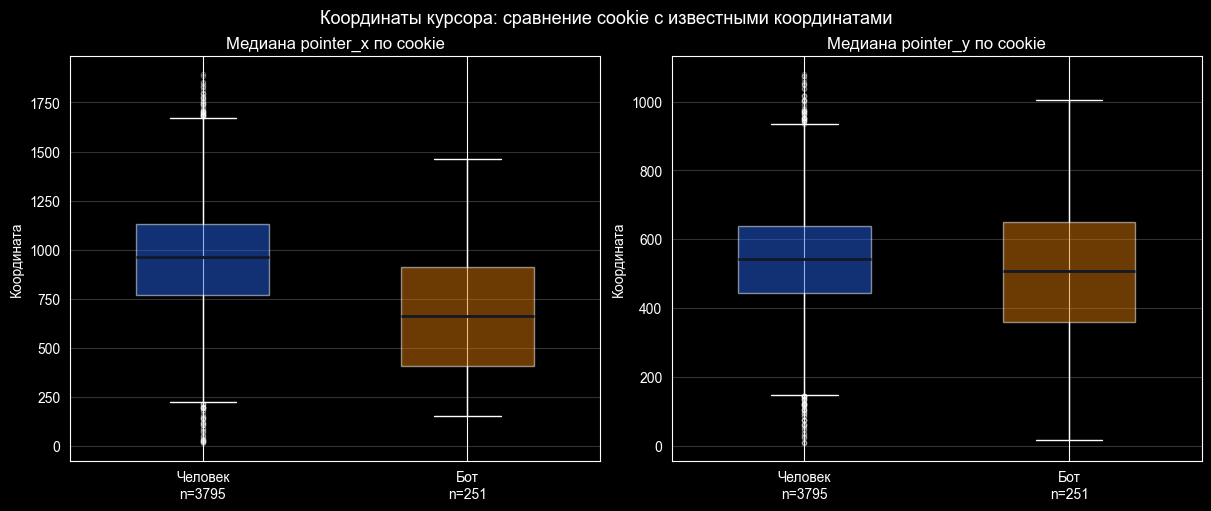

In [22]:
pointer_events = train_events_labeled.loc[
    train_events_labeled['platform'].eq('web')
    & train_events_labeled[['pointer_x', 'pointer_y']].notna().all(axis=1)
]
pointer_by_cookie = pointer_events.groupby(['cookie_id', 'target'], as_index=False).agg(
    pointer_x_median=('pointer_x', 'median'),
    pointer_y_median=('pointer_y', 'median'),
)
pointer_coverage = pd.DataFrame({
    'web_cookies': train_events_labeled.loc[train_events_labeled['platform'].eq('web')]
        .groupby('target')['cookie_id'].nunique(),
    'cookies_with_coordinates': pointer_by_cookie.groupby('target')['cookie_id'].nunique(),
}).reindex([0, 1]).fillna(0).astype(int)
pointer_coverage['with_coordinates_pct'] = (
    100 * pointer_coverage['cookies_with_coordinates'] / pointer_coverage['web_cookies']
).round(2)
display(pointer_coverage.rename(index={0: 'Человек', 1: 'Бот'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
for ax, column, title in [
    (axes[0], 'pointer_x_median', 'Медиана pointer_x по cookie'),
    (axes[1], 'pointer_y_median', 'Медиана pointer_y по cookie'),
]:
    samples = [pointer_by_cookie.loc[pointer_by_cookie['target'].eq(t), column] for t in [0, 1]]
    boxes = ax.boxplot(
        samples,
        tick_labels=[f'Человек\nn={len(samples[0])}', f'Бот\nn={len(samples[1])}'],
        patch_artist=True, widths=0.5, whis=1.5,
        medianprops={'color': '#111827', 'linewidth': 2},
        flierprops={'markersize': 3, 'alpha': 0.3},
    )
    for box, color in zip(boxes['boxes'], ['#2563eb', '#d97706']):
        box.set_facecolor(color)
        box.set_alpha(0.5)
    ax.set_title(title)
    ax.set_ylabel('Координата')
    ax.grid(axis='y', alpha=0.2)
    ax.set_axisbelow(True)
fig.suptitle('Координаты курсора: сравнение cookie с известными координатами', fontsize=13)
fig.savefig(plot_dir / 'bot_human_pointer_boxplots.png', dpi=160, bbox_inches='tight')
plt.show()


## Категориальные признаки для моделей

К 16 числовым признакам добавляем самые частые значения шести полей внутри окна:
`platform`, `ua_os`, `ua_client`, `item_category`, `item_location`, `seller_type`.
При одинаковой частоте выбираем первое значение по алфавиту. Если известных значений
нет, используем `unknown`. Это преобразование не использует `target`.

Для линейной модели категории кодирует `OneHotEncoder` внутри обучаемого `Pipeline`.
В CatBoost передаем категориальные столбцы через `cat_features`; он сам обрабатывает
категории при обучении. На валидации все преобразования обучаются только на прошлой
части train. В таблице результатов указано, какой набор признаков использует модель.


In [23]:
CATEGORICAL_SOURCES = [
    'platform', 'ua_os', 'ua_client', 'item_category', 'item_location', 'seller_type',
]


def categorical_features(ev, meta):
    features = meta[['cookie_id']].copy()
    for column in CATEGORICAL_SOURCES:
        counts = (
            ev[['cookie_id', column]].dropna()
            .groupby(['cookie_id', column]).size().rename('count').reset_index()
        )
        most_frequent = (
            counts.sort_values(['cookie_id', 'count', column], ascending=[True, False, True])
            .drop_duplicates('cookie_id')
            .set_index('cookie_id')[column]
        )
        features[f'{column}_mode'] = (
            features['cookie_id'].map(most_frequent).fillna('unknown').astype(str)
        )
    return features


numeric_cols = Xtr.columns.drop('cookie_id').tolist()
Xtr_extended = Xtr.merge(categorical_features(ev_tr, train), on='cookie_id', validate='one_to_one')
Xte_extended = Xte.merge(categorical_features(ev_te, test), on='cookie_id', validate='one_to_one')
categorical_cols = [f'{column}_mode' for column in CATEGORICAL_SOURCES]
feature_sets = {
    'numeric': (Xtr[numeric_cols], Xte[numeric_cols]),
    'with_categories': (
        Xtr_extended[numeric_cols + categorical_cols],
        Xte_extended[numeric_cols + categorical_cols],
    ),
}
print(f'Числовых признаков: {len(numeric_cols)}; категориальных: {len(categorical_cols)}')
print('Числовые:', numeric_cols)
print('Категориальные:', categorical_cols)
display(Xtr_extended[['cookie_id'] + categorical_cols].head(10))


Числовых признаков: 16; категориальных: 6
Числовые: ['n_events', 'event_type_nunique', 'item_nunique', 'item_category_nunique', 'item_location_nunique', 'search_query_nunique', 'n_search_results_view', 'n_item_view', 'n_photo_swipe', 'n_seller_page_view', 'n_contact_phone_show', 'n_contact_chat_open', 'n_contact_message_sent', 'n_favorite_add', 'n_login', 'n_captcha_shown']
Категориальные: ['platform_mode', 'ua_os_mode', 'ua_client_mode', 'item_category_mode', 'item_location_mode', 'seller_type_mode']


,cookie_id,platform_mode,ua_os_mode,ua_client_mode,item_category_mode,item_location_mode,seller_type_mode
0,ck_54a059eb7d3ea68b,android,android,avito_app,kvartiry_prodazha,sankt-peterburg,pro
1,ck_7e4de46eeab82974,web,windows,yandex,kvartiry_arenda,vladivostok,private
2,ck_9320229ef6304522,web,windows,chrome,detskie_tovary,novosibirsk,pro
3,ck_30ccd25bc1714ed9,web,windows,chrome,detskie_tovary,cheboksary,private
4,ck_a77c5f05948cdeef,web,macos,chrome,kvartiry_prodazha,ekaterinburg,private
5,ck_ea6f843af2292fec,web,macos,chrome,kvartiry_arenda,moskva,private
6,ck_e38634dc2f188574,android,android,chrome,kvartiry_prodazha,kazan,private
7,ck_ad7f01440bb250d1,android,android,chrome,hobbi,ulyanovsk,private
8,ck_a7a58d28a4482bdc,web,windows,firefox,zhivotnye,ekaterinburg,pro
9,ck_e00e1e6c2a2ab4ac,android,android,avito_app,uslugi,sankt-peterburg,private


## Сравнение локальных моделей на временной валидации

Обучаемся на окнах раньше 17 апреля 2026 года, проверяемся на более поздних окнах
из train. Масштабирование и кодирование категорий обучаются только на обучающей части.

Сравниваем логистическую регрессию с разной силой L2-регуляризации (`C`),
`SGDClassifier(loss='log_loss')` с L2 и ElasticNet и CatBoost. SGD — способ обучения
линейной модели стохастическим градиентным спуском; CatBoost — градиентный бустинг деревьев.
Чем меньше `C`, тем сильнее регуляризация логистической регрессии.

Основная метрика из `TASK.md` — максимальный Precision при Recall ≥ 70%; считаем ее
официальной функцией из `metric.py`, учитывающей равные оценки. Дополнительно считаем
PR-AUC (метод трапеций) и ROC-AUC. Модели ранжируем по основной метрике.
CatBoost с категориями и без них сравнивается отдельно, чтобы видеть вклад категорий.

Все модели работают локально, не обращаются к внешним API и имеют значительно меньше
1B параметров. Версии библиотек зафиксированы в `requirements.txt`.


In [24]:
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from metric import precision_at_recall

is_valid = train['window_start_ts'].ge('2026-04-17').to_numpy()
cols = numeric_cols


def make_linear_pipeline(classifier, log_counts=True):
    steps = []
    if log_counts:
        steps.append(('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')))
    steps.extend([('scale', StandardScaler()), ('classifier', classifier)])
    return Pipeline(steps)


def make_logistic_model(log_counts=True, class_weight=None, C=1.0):
    return make_linear_pipeline(
        LogisticRegression(C=C, max_iter=2000, class_weight=class_weight, random_state=0),
        log_counts=log_counts,
    )


numeric_transformer = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler()),
])
onehot_logistic = Pipeline([
    ('preprocess', ColumnTransformer([
        ('numeric', numeric_transformer, numeric_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ])),
    ('classifier', LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=0)),
])
catboost_params = dict(
    iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=5,
    loss_function='Logloss', auto_class_weights='Balanced',
    random_seed=0, thread_count=4, verbose=False, allow_writing_files=False,
)

model_specs = {
    'lr_counts_l2_c1': dict(
        label='LogReg: счетчики, L2, C=1', family='LogReg', feature_set='numeric',
        estimator=make_logistic_model(log_counts=False),
    ),
    'lr_log1p_l2_c1': dict(
        label='LogReg: log1p, L2, C=1', family='LogReg', feature_set='numeric',
        estimator=make_logistic_model(),
    ),
    'lr_log1p_balanced_l2_c1': dict(
        label='LogReg: log1p, balanced, L2, C=1', family='LogReg', feature_set='numeric',
        estimator=make_logistic_model(class_weight='balanced'),
    ),
    'lr_log1p_balanced_l2_c01': dict(
        label='LogReg: log1p, balanced, L2, C=0.1', family='LogReg', feature_set='numeric',
        estimator=make_logistic_model(class_weight='balanced', C=0.1),
    ),
    'lr_log1p_balanced_l2_c10': dict(
        label='LogReg: log1p, balanced, L2, C=10', family='LogReg', feature_set='numeric',
        estimator=make_logistic_model(class_weight='balanced', C=10.0),
    ),
    'sgd_logloss_l2': dict(
        label='SGD: log_loss, L2', family='SGD', feature_set='numeric',
        estimator=make_linear_pipeline(SGDClassifier(
            loss='log_loss', penalty='l2', alpha=0.001, class_weight='balanced',
            average=True, max_iter=3000, tol=1e-4, random_state=0,
        )),
    ),
    'sgd_logloss_elasticnet': dict(
        label='SGD: log_loss, ElasticNet', family='SGD', feature_set='numeric',
        estimator=make_linear_pipeline(SGDClassifier(
            loss='log_loss', penalty='elasticnet', alpha=0.001, l1_ratio=0.15,
            class_weight='balanced', average=True, max_iter=3000, tol=1e-4, random_state=0,
        )),
    ),
    'lr_log1p_onehot_l2': dict(
        label='LogReg: log1p + one-hot, balanced', family='LogReg', feature_set='with_categories',
        estimator=onehot_logistic,
    ),
    'catboost_numeric': dict(
        label='CatBoost: числовые признаки', family='CatBoost', feature_set='numeric',
        estimator=CatBoostClassifier(**catboost_params),
    ),
    'catboost_categories': dict(
        label='CatBoost: числовые + категории', family='CatBoost', feature_set='with_categories',
        estimator=CatBoostClassifier(**catboost_params, cat_features=categorical_cols),
    ),
}

validation_rows = []
validation_predictions = {}
candidate_models = {}
for model_id, spec in model_specs.items():
    X_model, _ = feature_sets[spec['feature_set']]
    candidate = spec['estimator']
    candidate.fit(X_model.loc[~is_valid], ytr[~is_valid])
    scores = candidate.predict_proba(X_model.loc[is_valid])[:, 1]
    validation_predictions[model_id] = scores
    candidate_models[model_id] = candidate
    precision, recall, _ = precision_recall_curve(ytr[is_valid], scores)
    validation_rows.append({
        'model_id': model_id, 'Модель': spec['label'], 'Семейство': spec['family'],
        'Признаки': spec['feature_set'], 'Число входных признаков': X_model.shape[1],
        'P@R>=0.7': precision_at_recall(ytr[is_valid], scores),
        'PR-AUC': auc(recall, precision),
        'ROC-AUC': roc_auc_score(ytr[is_valid], scores),
    })

validation_results = pd.DataFrame(validation_rows).sort_values(
    'P@R>=0.7', ascending=False, kind='stable',
).reset_index(drop=True)
display(validation_results.round(4))
print(f'Обучение: {(~is_valid).sum()} cookie; валидация: {is_valid.sum()} cookie')
print(f'P@R>=0.7 для постоянной оценки: {ytr[is_valid].mean():.4f}')

best_model_id = validation_results.loc[0, 'model_id']
model = candidate_models[best_model_id]
p_va = validation_predictions[best_model_id]
print(f'Лучший вариант по P@R>=0.7: {best_model_id}')

best_linear_id = validation_results.loc[
    validation_results['Семейство'].eq('LogReg'), 'model_id'
].iloc[0]
best_linear = candidate_models[best_linear_id]
linear_feature_names = best_linear[:-1].get_feature_names_out()
feature_coefficients = pd.DataFrame({
    'Признак': linear_feature_names,
    'Коэффициент': best_linear.named_steps['classifier'].coef_[0],
}).sort_values('Коэффициент', key=lambda values: values.abs(), ascending=False)
print(f'Коэффициенты лучшей логистической регрессии: {best_linear_id}')
display(feature_coefficients.head(20).round(4))


/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

,model_id,Модель,Семейство,Признаки,Число входных признаков,P@R>=0.7,PR-AUC,ROC-AUC
0,catboost_categories,CatBoost: числовые + категории,CatBoost,with_categories,22,0.3052,0.5333,0.8457
1,lr_log1p_balanced_l2_c1,"LogReg: log1p, balanced, L2, C=1",LogReg,numeric,16,0.2843,0.4423,0.8289
2,lr_log1p_balanced_l2_c10,"LogReg: log1p, balanced, L2, C=10",LogReg,numeric,16,0.2786,0.4417,0.8285
3,lr_log1p_balanced_l2_c01,"LogReg: log1p, balanced, L2, C=0.1",LogReg,numeric,16,0.2732,0.4424,0.8309
4,sgd_logloss_l2,"SGD: log_loss, L2",SGD,numeric,16,0.2699,0.4429,0.8314
5,lr_log1p_l2_c1,"LogReg: log1p, L2, C=1",LogReg,numeric,16,0.2528,0.4458,0.8269
6,lr_counts_l2_c1,"LogReg: счетчики, L2, C=1",LogReg,numeric,16,0.2348,0.4226,0.8118
7,lr_log1p_onehot_l2,"LogReg: log1p + one-hot, balanced",LogReg,with_categories,22,0.2311,0.4607,0.8286
8,catboost_numeric,CatBoost: числовые признаки,CatBoost,numeric,16,0.2218,0.4697,0.8319
9,sgd_logloss_elasticnet,"SGD: log_loss, ElasticNet",SGD,numeric,16,0.1094,0.1492,0.6646


Обучение: 9140 cookie; валидация: 1951 cookie
P@R>=0.7 для постоянной оценки: 0.0820
Лучший вариант по P@R>=0.7: catboost_categories
Коэффициенты лучшей логистической регрессии: lr_log1p_balanced_l2_c1


,Признак,Коэффициент
2,item_nunique,2.5821
6,n_search_results_view,1.1680
5,search_query_nunique,-1.0691
4,item_location_nunique,1.0249
8,n_photo_swipe,-0.9325
7,n_item_view,-0.8793
3,item_category_nunique,-0.8161
13,n_favorite_add,-0.7355
0,n_events,-0.2849
1,event_type_nunique,-0.2680


## Отдельный submission для каждого варианта

После сравнения на временной валидации заново обучаем каждый вариант на всем train.
Для каждого создаем свой `submissions/<model_id>.csv` с колонками `cookie_id, score`.
Оценки в таблице остаются результатами временной валидации; метки test не используются.
`submissions/model_comparison.csv` связывает имена файлов с метриками и вариантами моделей.


In [25]:
from sklearn.base import clone

submission_dir = Path('submissions')
submission_dir.mkdir(exist_ok=True)
final_models = {}
submission_rows = []
for model_id, spec in model_specs.items():
    X_model, X_test_model = feature_sets[spec['feature_set']]
    final_model = clone(spec['estimator'])
    final_model.fit(X_model, ytr)
    scores = final_model.predict_proba(X_test_model)[:, 1]
    sub = pd.DataFrame({'cookie_id': test['cookie_id'], 'score': scores})
    assert sub['cookie_id'].equals(test['cookie_id'])
    assert len(sub) == len(test) and sub['cookie_id'].is_unique
    assert np.isfinite(sub['score']).all() and sub['score'].between(0, 1).all()

    submission_path = submission_dir / f'{model_id}.csv'
    sub.to_csv(submission_path, index=False)
    final_models[model_id] = final_model
    submission_rows.append({'model_id': model_id, 'submission_file': str(submission_path)})

submission_manifest = validation_results.merge(
    pd.DataFrame(submission_rows), on='model_id', validate='one_to_one',
)
submission_manifest.to_csv(submission_dir / 'model_comparison.csv', index=False)
display(submission_manifest[['model_id', 'P@R>=0.7', 'PR-AUC', 'ROC-AUC', 'submission_file']].round(4))
print(f'Сохранено submissions: {len(submission_rows)}; строк в каждом: {len(test)}')
print(f'Лучший на временной валидации: {submission_dir / (best_model_id + ".csv")}')


/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/slvic/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

,model_id,P@R>=0.7,PR-AUC,ROC-AUC,submission_file
0,catboost_categories,0.3052,0.5333,0.8457,submissions/catboost_categories.csv
1,lr_log1p_balanced_l2_c1,0.2843,0.4423,0.8289,submissions/lr_log1p_balanced_l2_c1.csv
2,lr_log1p_balanced_l2_c10,0.2786,0.4417,0.8285,submissions/lr_log1p_balanced_l2_c10.csv
3,lr_log1p_balanced_l2_c01,0.2732,0.4424,0.8309,submissions/lr_log1p_balanced_l2_c01.csv
4,sgd_logloss_l2,0.2699,0.4429,0.8314,submissions/sgd_logloss_l2.csv
5,lr_log1p_l2_c1,0.2528,0.4458,0.8269,submissions/lr_log1p_l2_c1.csv
6,lr_counts_l2_c1,0.2348,0.4226,0.8118,submissions/lr_counts_l2_c1.csv
7,lr_log1p_onehot_l2,0.2311,0.4607,0.8286,submissions/lr_log1p_onehot_l2.csv
8,catboost_numeric,0.2218,0.4697,0.8319,submissions/catboost_numeric.csv
9,sgd_logloss_elasticnet,0.1094,0.1492,0.6646,submissions/sgd_logloss_elasticnet.csv


Сохранено submissions: 10; строк в каждом: 4909
Лучший на временной валидации: submissions/catboost_categories.csv


## Поведенческие признаки: отбор и итоговая проверка

Новая модель получила **Precision@Recall≥0.70 = 0.53081** на 17–19 апреля
против **0.30518** у исходного CatBoost с категориями. Это локальная оценка;
скрытый тест для нового файла еще не проверен. Параметры CatBoost прежние.

Вместо добавления всех полей сравниваем группы признаков на ранних временных
разбиениях: обучение до 12 апреля → проверка 12–14 апреля; обучение до 15 апреля
→ проверка 15–16 апреля. Ранжирование отдельных признаков обучено только до
12 апреля. Последние три дня не участвуют в выборе новых признаков.

Из 80 кандидатов, проверенных отдельными группами, оставлены 30:

* интервалы между событиями, их разброс, доли коротких/длинных и повторных интервалов;
* разнообразие и повторяемость объявлений, категорий, городов, запросов, действий;
* пять счетчиков: просмотры объявлений, страницы продавцов, листания фотографий,
  число категорий и городов.

На ранних разбиениях средняя метрика исходной модели — 0.28043; лучшего широкого
набора — 0.51281; выбранных 30 признаков — 0.50446. Берем самый короткий набор
в пределах 0.015 от лучшего среднего результата. Список зафиксирован в
`selected_features.json` **до** итоговой проверки.

`user_agent` разобран на семейство клиента, ОС и признаки автоматизации; исходная
строка с версиями ПО и устройством не передается в модель. UA улучшает широкий
набор, но не входит в выбранные top-30. Добавление признаков сессий и глубины
выдачи к лучшему широкому набору не улучшило среднюю метрику. Сырые координаты,
ID, версии браузера и абсолютные даты не используются.

В файле 4 863 полных дубликата, строки не упорядочены по времени. Новая функция
удаляет дубликаты, отбирает строго `[window_start_ts, window_end_ts)` и сортирует
события внутри куки. 40 209 событий вне окон исключены. Структурные пропуски
не подменяются нулями; неопределенные статистики остаются NaN.

Подробные определения, результаты сравнений и ограничения: [BEHAVIOR_REPORT.md](BEHAVIOR_REPORT.md).
Ячейки ниже можно выполнить отдельно от старого baseline: данные загружаются заново.


In [26]:
import json
import sys
from pathlib import Path
import pandas as pd

# Поддерживаем запуск из папки ноутбука и из корня репозитория.
behavior_root = Path.cwd()
if not (behavior_root / 'behavior_features.py').exists():
    behavior_root = behavior_root / 'bot_detection_challenge'
if str(behavior_root.resolve()) not in sys.path:
    sys.path.insert(0, str(behavior_root.resolve()))

from behavior_features import build_features, read_data
from behavior_experiments import ARTIFACTS, ROOT, final_run

behavior_train, behavior_test, behavior_events = read_data(ROOT / 'data')
behavior_meta = pd.concat(
    [behavior_train.drop(columns='target'), behavior_test], ignore_index=True,
)
behavior_features, behavior_groups, behavior_audit = build_features(behavior_events, behavior_meta)
behavior_X = behavior_features.loc[behavior_train.cookie_id]
behavior_Xtest = behavior_features.loc[behavior_test.cookie_id]
behavior_selection = json.loads((ROOT / 'selected_features.json').read_text())
selected_columns = behavior_selection['features']
print('Python:', sys.version.split()[0])
print(f'Рассчитано кандидатов: {behavior_features.shape[1]}; в обучение пойдут: {len(selected_columns)}')
print('Дубликатов:', behavior_audit['exact_duplicates'])
print('Событий вне окон:', behavior_audit['rows_outside_windows'])
print('Матрицы выбранных признаков:', behavior_X[selected_columns].shape, behavior_Xtest[selected_columns].shape)


Python: 3.14.3
Рассчитано кандидатов: 80; в обучение пойдут: 30
Дубликатов: 4863
Событий вне окон: 40209
Матрицы выбранных признаков: (11091, 30) (4909, 30)


### Одна итоговая проверка и обучение на всем train

Функция ниже проверяет зафиксированные признаки на 17–19 апреля,
переобучает выбранную модель на всем train и создает
`submissions/catboost_behavior_selected.csv`. Параметры и random_seed=0
сверяются с сохраненной конфигурацией. Старые submissions сохраняются.

Для повторения отбора с нуля из корня проекта:

```bash
.venv/bin/python bot_detection_challenge/behavior_experiments.py compare
.venv/bin/python bot_detection_challenge/behavior_experiments.py refine
```

Не следует менять список признаков по результату следующей ячейки:
тогда последние три дня тоже станут частью подбора.


In [27]:
ARTIFACTS.mkdir(parents=True, exist_ok=True)
final_run(behavior_train, behavior_test, behavior_X, behavior_Xtest, behavior_groups)


Final holdout (not used to select features):
                  model_id  n_features  precision_at_recall_70   pr_auc  roc_auc
       baseline_categories          22                0.305177 0.533304 0.845750
catboost_behavior_selected          30                0.530806 0.672365 0.891515
Saved /Users/slvic/ANYA/avito_bot_detection/bot_detection_challenge/submissions/catboost_behavior_selected.csv (4909 rows)


In [28]:
# Важности описывают уже выбранную модель; они не используются для нового отбора.
behavior_importance = pd.read_csv(ARTIFACTS / 'holdout_feature_importance.csv')
display(behavior_importance.head(15).round(3))

behavior_submission_path = ROOT / 'submissions' / 'catboost_behavior_selected.csv'
behavior_submission = pd.read_csv(behavior_submission_path)
print('Файл для отправки:', behavior_submission_path.relative_to(ROOT))
print('Строк:', len(behavior_submission))
display(behavior_submission.head())


,feature,importance
0,gap_median,12.559
1,gap_iqr_over_median,6.695
2,gap_min,6.668
3,item_unique_share,5.621
4,location_unique_share,3.797
5,gap_gt_30m_share,3.379
6,location_entropy,3.238
7,location_top_share,3.222
8,category_unique_share,3.215
9,event_top_share,3.136


Файл для отправки: submissions/catboost_behavior_selected.csv
Строк: 4909


,cookie_id,score
0,ck_315fb710a0e371e7,0.001550
1,ck_a76ee3b3e3e522fd,0.085343
2,ck_94c9a4d382689e82,0.304287
3,ck_8eaf9509ad9462a0,0.008436
4,ck_9a88a5a989cb5bc6,0.019267


## Совместные координаты X и Y: проверка гипотезы

Геометрия пар `(x, y)` и последовательных перемещений проверена отдельно от
предыдущих 30 признаков. Вычислены 12 кандидатов: доступность координат (2),
повторяемость пар (2), форма облака точек (3), нормированные перемещения (3),
направления (2). Сырые X/Y в модель не передаются.

Проверены 12 вариантов на двух ранних временных разбиениях. Только наличие/число
координат дало среднюю метрику 0.50778 против 0.50446 у прежней модели.
Геометрия с повторяемостью пар дала 0.55959, а сочетание всех 12 XY-кандидатов —
0.57036. Выбор зафиксирован в `pointer_selection.json` до финального сравнения.
По заранее заданному правилу выбран самый компактный вариант в пределах 0.01
от лучшего: здесь это 30 прежних + 12 новых признаков. Разница с компактным
вариантом мала; отдельные группы перемещений и направлений прироста не дали.

| Проверка | Прежние 30 | С XY, 42 |
|---|---:|---:|
| 12–14 апреля | 0.43750 | 0.50763 |
| 15–16 апреля | 0.57143 | 0.63309 |
| Итоговая: 17–19 апреля | 0.53081 | **0.55340** |

Улучшение на последнем отрезке — **2.26 процентного пункта**. Этот отрезок уже
использовался раньше, поэтому независимым новым тестом не является. При 160 ботах
оценка шумная: ориентировочный 95% bootstrap-интервал прибавки [-0.052, +0.149]
содержит ноль. Результат на скрытом тесте пока неизвестен.

Признак вытянутости облака `xy_anisotropy` стал пятым по стандартной важности
CatBoost. Он совместно учитывает X и Y через ковариационную матрицу. Его значение
близко к 1 у облака вдоль линии и к 0 при одинаковом разбросе во всех направлениях.
Для неподвижной точки признак не определен и остается NaN.

Это позиции в моменты событий, а не непрерывная траектория мыши. Пропуски,
non-web события, неоднозначные временные метки и паузы >30 минут разрывают
последовательность. Геометрия центрирована, длины перемещений нормированы по
разбросу самой куки. Размеры экрана не угадываются.

Код: `pointer_features.py`, `pointer_experiments.py`.
Подробные определения и ограничения: [POINTER_REPORT.md](POINTER_REPORT.md).
Ячейки ниже можно выполнять независимо от предыдущих разделов.


In [29]:
import json
import sys
from pathlib import Path
import pandas as pd

xy_root = Path.cwd()
if not (xy_root / 'pointer_features.py').exists():
    xy_root = xy_root / 'bot_detection_challenge'
if str(xy_root.resolve()) not in sys.path:
    sys.path.insert(0, str(xy_root.resolve()))

from pointer_experiments import (
    ARTIFACTS as XY_ARTIFACTS, ROOT as XY_ROOT,
    prepare_matrices as prepare_xy_matrices, final_run as final_xy_run,
)

xy_config = json.loads((XY_ROOT / 'pointer_selection.json').read_text())
print('Выбранный вариант:', xy_config['candidate'])
print('Признаков:', len(xy_config['features']))
print('Новые признаки:', [c for c in xy_config['features'] if c.startswith('xy_')])
xy_development = pd.read_csv(XY_ARTIFACTS / 'development_summary.csv')
display(xy_development.round(5))


Выбранный вариант: xy_joint_coverage
Признаков: 42
Новые признаки: ['xy_n_points', 'xy_observed_share', 'xy_repeat_share', 'xy_top_point_share', 'xy_abs_correlation', 'xy_anisotropy', 'xy_radius_cv', 'xy_zero_step_share', 'xy_step_median_normalized', 'xy_step_cv', 'xy_turn_cos_mean', 'xy_repeated_vector_share']


,model_id,n_features,mean_precision,min_precision,mean_pr_auc
0,xy_joint_coverage,42,0.57036,0.50763,0.71520
1,xy_spatial,35,0.55959,0.50379,0.71482
2,xy_geometry_coverage,35,0.55745,0.46996,0.71677
3,xy_spatial_coverage,37,0.55168,0.48364,0.71148
4,xy_joint,40,0.53028,0.46996,0.70793
5,coverage_only,32,0.50778,0.44040,0.69310
6,behavior_30,30,0.50446,0.43750,0.69064
7,xy_geometry,33,0.49900,0.43750,0.71038
8,xy_steps,33,0.49549,0.41956,0.68607
9,xy_motion,35,0.49353,0.41562,0.68116


### Пересоздать XY-submission

Следующая ячейка повторяет итоговую проверку зафиксированного набора,
обучает его на всем train и сохраняет отдельный
`submissions/catboost_behavior_xy.csv`. Предыдущий submission сохраняется.

Для полного повторения сравнения кандидатов из корня проекта:

```bash
.venv/bin/python bot_detection_challenge/pointer_experiments.py compare
.venv/bin/python bot_detection_challenge/pointer_experiments.py final
```


In [30]:
xy_train, xy_test, xy_X, xy_Xtest = prepare_xy_matrices()
xy_results = final_xy_run(xy_train, xy_test, xy_X, xy_Xtest)


Final comparison (previously seen dates):
   model_id  n_features  precision_at_recall_70   pr_auc  roc_auc
behavior_30          30                0.530806 0.672365 0.891515
behavior_xy          42                0.553398 0.697047 0.906440
Saved experimental submission: /Users/slvic/ANYA/avito_bot_detection/bot_detection_challenge/submissions/catboost_behavior_xy.csv


In [31]:
xy_importance = pd.read_csv(XY_ARTIFACTS / 'final_feature_importance.csv')
display(xy_importance.head(15).round(3))

xy_submission_path = XY_ROOT / 'submissions' / 'catboost_behavior_xy.csv'
xy_submission = pd.read_csv(xy_submission_path)
print('Файл для отправки:', xy_submission_path.relative_to(XY_ROOT))
print('Строк:', len(xy_submission))
display(xy_submission.head())


,feature,importance
0,gap_median,10.857
1,gap_min,6.315
2,gap_iqr_over_median,6.189
3,item_unique_share,5.251
4,xy_anisotropy,4.236
5,category_entropy,3.625
6,event_entropy,3.548
7,location_unique_share,3.396
8,category_unique_share,3.063
9,gap_gt_30m_share,3.026


Файл для отправки: submissions/catboost_behavior_xy.csv
Строк: 4909


,cookie_id,score
0,ck_315fb710a0e371e7,0.000917
1,ck_a76ee3b3e3e522fd,0.295030
2,ck_94c9a4d382689e82,0.283997
3,ck_8eaf9509ad9462a0,0.010631
4,ck_9a88a5a989cb5bc6,0.019053
